# 05 — Stacking Ensemble (Improved)
**Ensemble Early Parkinson Detection Using Voice Biomarkers**

This notebook implements an improved stacking ensemble with three key changes from the initial attempt:

1. **Common feature set (SVM-RFE)** for all base learners — simplifies stacking and reduces noise
2. **5 base learners** — adding Logistic_L2 (our best individual model)
3. **Enriched meta-features** — probabilities + hard predictions + confidence margins (15 features instead of 5)
4. **Class-weighted meta-learner** — addresses the 3:1 imbalance at the meta-level

| Level-0 Base Learner | Family | Tuned Hyperparameters |
|---|---|---|
| SVM_RBF | Kernel | C=100, gamma=0.001 |
| KNN | Instance-based | k=15, uniform, euclidean |
| Random Forest | Tree Ensemble | max_depth=3, 50 trees |
| Logistic L1 | Linear (sparse) | C=1 |
| Logistic L2 | Linear (ridge) | C=0.1 |

All base learners use SVM-RFE features (10 features) with `class_weight='balanced'` where supported.

**Level-1 Meta-learner:** Logistic Regression (L2, `class_weight='balanced'`)

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from imblearn.pipeline import Pipeline as ImbPipeline

from src.data_utils import load_parkinsons, get_X_y_groups, FEATURE_COLS
from src.eval_utils import (
    compute_metrics, results_to_dataframe, plot_confusion_matrix
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
N_OUTER = 5
N_INNER = 5

df = load_parkinsons()
X, y, groups = get_X_y_groups(df)
print(f'X: {X.shape}, y: {y.shape}, Subjects: {groups.nunique()}')

X: (195, 22), y: (195,), Subjects: 32


## 2. Define Base Learners — Common Feature Set

In [2]:
# Common feature set: SVM-RFE (dominated in NB03 for 4 of 6 models)
SVM_RFE_FEATURES = [
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ',
    'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE'
]

# Common feature matrix for all base learners
X_common = X[SVM_RFE_FEATURES]
print(f'Common feature set: {len(SVM_RFE_FEATURES)} features')
print(f'Features: {SVM_RFE_FEATURES}')

# 5 base learners with tuned hyperparameters from NB04
BASE_LEARNERS = {
    'SVM_RBF': SVC(
        kernel='rbf', C=100, gamma=0.001, class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=15, weights='uniform', metric='euclidean'
    ),
    'Random_Forest': RandomForestClassifier(
        n_estimators=50, max_depth=3, min_samples_split=10,
        min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L1': LogisticRegression(
        penalty='l1', C=1, solver='saga', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Logistic_L2': LogisticRegression(
        penalty='l2', C=0.1, solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}

# Class-weighted meta-learner
META_LEARNER = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=5000,
    class_weight='balanced', random_state=RANDOM_STATE
)

print(f'\nBase learners ({len(BASE_LEARNERS)}): {list(BASE_LEARNERS.keys())}')
print(f'Meta-learner: Logistic Regression (L2, C=1.0, class_weight=balanced)')

Common feature set: 10 features
Features: ['MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:APQ', 'spread1', 'D2', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'NHR', 'PPE']

Base learners (5): ['SVM_RBF', 'KNN', 'Random_Forest', 'Logistic_L1', 'Logistic_L2']
Meta-learner: Logistic Regression (L2, C=1.0, class_weight=balanced)


## 3. Enriched Meta-Feature Generation

For each base learner, we generate **three** types of meta-features:
1. **Probability** of PD (class 1) — continuous confidence estimate
2. **Hard prediction** (0 or 1) — binary vote
3. **Confidence margin** = |P(PD) - 0.5| — how certain the model is

This gives us 5 × 3 = 15 meta-features instead of 5, providing the meta-learner with richer information about each base learner's behavior.

In [3]:
def build_base_pipeline(clf):
    """Wrap a classifier in a StandardScaler pipeline."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])


def get_enriched_meta_features(pipe, X_data):
    """
    Generate enriched meta-features from a fitted pipeline:
    [probability, hard_prediction, confidence_margin]
    """
    if hasattr(pipe, 'predict_proba'):
        proba = pipe.predict_proba(X_data)[:, 1]
    else:
        proba = pipe.predict(X_data).astype(float)
    
    hard_pred = pipe.predict(X_data).astype(float)
    confidence = np.abs(proba - 0.5)
    
    return proba, hard_pred, confidence


def generate_enriched_oof(base_learners, X_feat, y, groups, n_splits=5):
    """
    Generate enriched out-of-fold meta-features for all base learners.
    
    Returns:
        meta_X: np.array of shape (n_samples, n_models * 3)
        meta_y: np.array of shape (n_samples,)
        feature_names: list of meta-feature names
    """
    n_samples = len(y)
    n_models = len(base_learners)
    meta_X = np.zeros((n_samples, n_models * 3))
    
    inner_cv = GroupKFold(n_splits=n_splits)
    
    for model_idx, (name, clf) in enumerate(base_learners.items()):
        for train_idx, val_idx in inner_cv.split(X_feat, y, groups):
            pipe = build_base_pipeline(clone(clf))
            
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                pipe.fit(X_feat.iloc[train_idx], y.iloc[train_idx])
            
            proba, hard_pred, confidence = get_enriched_meta_features(
                pipe, X_feat.iloc[val_idx]
            )
            
            col_base = model_idx * 3
            meta_X[val_idx, col_base] = proba
            meta_X[val_idx, col_base + 1] = hard_pred
            meta_X[val_idx, col_base + 2] = confidence
    
    feature_names = []
    for name in base_learners.keys():
        feature_names.extend([f'{name}_prob', f'{name}_pred', f'{name}_conf'])
    
    return meta_X, y.values, feature_names


def train_and_predict_enriched(base_learners, X_train, y_train, X_test):
    """
    Train all base learners on full training set and generate
    enriched meta-features for the test set.
    """
    n_test = len(X_test)
    n_models = len(base_learners)
    meta_X_test = np.zeros((n_test, n_models * 3))
    
    fitted_pipelines = {}
    
    for model_idx, (name, clf) in enumerate(base_learners.items()):
        pipe = build_base_pipeline(clone(clf))
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            pipe.fit(X_train, y_train)
        
        fitted_pipelines[name] = pipe
        
        proba, hard_pred, confidence = get_enriched_meta_features(pipe, X_test)
        
        col_base = model_idx * 3
        meta_X_test[:, col_base] = proba
        meta_X_test[:, col_base + 1] = hard_pred
        meta_X_test[:, col_base + 2] = confidence
    
    return meta_X_test, fitted_pipelines


def run_stacking_cv(base_learners, X_feat, y, groups, meta_learner,
                    n_outer=5, n_inner=5):
    """
    Run full stacking with subject-wise outer CV. Reusable for any set of base learners.
    
    Returns dict with all results.
    """
    outer_cv = GroupKFold(n_splits=n_outer)
    
    s_y_trues, s_y_preds, s_y_probs = [], [], []
    s_fold_metrics = []
    s_meta_weights = []
    b_y_preds = {name: [] for name in base_learners}
    b_y_trues = {name: [] for name in base_learners}
    
    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_feat, y, groups)):
        X_tr, X_te = X_feat.iloc[train_idx], X_feat.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        groups_tr = groups.iloc[train_idx]
        
        # Step 1: OOF meta-features
        meta_X_tr, meta_y_tr, feat_names = generate_enriched_oof(
            base_learners, X_tr, y_tr, groups_tr, n_splits=n_inner
        )
        
        # Step 2: Train meta-learner
        meta = clone(meta_learner)
        meta.fit(meta_X_tr, meta_y_tr)
        s_meta_weights.append(meta.coef_[0])
        
        # Step 3: Train base learners on full training set + predict test
        meta_X_te, fitted_pipes = train_and_predict_enriched(
            base_learners, X_tr, y_tr, X_te
        )
        
        # Step 4: Meta-learner predicts
        y_pred = meta.predict(meta_X_te)
        y_prob = meta.predict_proba(meta_X_te)[:, 1]
        
        s_y_trues.append(y_te.values)
        s_y_preds.append(y_pred)
        s_y_probs.append(y_prob)
        s_fold_metrics.append(compute_metrics(y_te, y_pred, y_prob))
        
        for name, pipe in fitted_pipes.items():
            b_y_preds[name].append(pipe.predict(X_te))
            b_y_trues[name].append(y_te.values)
    
    metrics_df = pd.DataFrame(s_fold_metrics)
    
    return {
        'y_trues': s_y_trues, 'y_preds': s_y_preds, 'y_probs': s_y_probs,
        'fold_metrics': s_fold_metrics,
        'mean_metrics': metrics_df.mean().to_dict(),
        'std_metrics': metrics_df.std().to_dict(),
        'meta_weights': s_meta_weights,
        'meta_feature_names': feat_names,
        'base_y_preds': b_y_preds,
        'base_y_trues': b_y_trues,
    }


print('Stacking helper functions defined (reusable for any base learner subset).')

Stacking helper functions defined (reusable for any base learner subset).


## 4. Run 5-Model Stacking

In [4]:
print('Running 5-model stacking ensemble...\n')

results_5model = run_stacking_cv(
    BASE_LEARNERS, X_common, y, groups, META_LEARNER,
    n_outer=N_OUTER, n_inner=N_INNER
)

print('=== 5-Model Stacking Results ===\n')
for metric in ['balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'mcc', 'auc_roc']:
    m = results_5model['mean_metrics'][metric]
    s = results_5model['std_metrics'][metric]
    print(f'  {metric:>20s}: {m:.4f} ± {s:.4f}')

per_fold_ba = [round(m['balanced_accuracy'], 4) for m in results_5model['fold_metrics']]
print(f'\nPer-fold BA: {per_fold_ba}')

Running 5-model stacking ensemble...

=== 5-Model Stacking Results ===

     balanced_accuracy: 0.7008 ± 0.1379
           sensitivity: 0.8184 ± 0.0977
           specificity: 0.5833 ± 0.3118
                    f1: 0.8354 ± 0.0540
                   mcc: 0.3734 ± 0.2240
               auc_roc: 0.8175 ± 0.1196

Per-fold BA: [0.8871, 0.7733, 0.5188, 0.6667, 0.6583]


## 5. Ablation Study (5-Model)

In [5]:
ablation_results = {}

for remove_name in BASE_LEARNERS.keys():
    subset = {k: v for k, v in BASE_LEARNERS.items() if k != remove_name}
    print(f'  Running without {remove_name}...')
    
    res = run_stacking_cv(subset, X_common, y, groups, META_LEARNER,
                          n_outer=N_OUTER, n_inner=N_INNER)
    
    all_yt = np.concatenate(res['y_trues'])
    all_yp = np.concatenate(res['y_preds'])
    all_yprob = np.concatenate(res['y_probs'])
    ablation_results[f'Without {remove_name}'] = compute_metrics(all_yt, all_yp, all_yprob)

# Full stacking
all_yt_5 = np.concatenate(results_5model['y_trues'])
all_yp_5 = np.concatenate(results_5model['y_preds'])
all_yprob_5 = np.concatenate(results_5model['y_probs'])
ablation_results['Full Stacking (5 models)'] = compute_metrics(all_yt_5, all_yp_5, all_yprob_5)

ablation_df = results_to_dataframe(ablation_results)
print('\n--- Ablation Study ---\n')
print(ablation_df.to_string())

# Identify which removal helps most
full_ba = ablation_results['Full Stacking (5 models)']['balanced_accuracy']
print('\nContribution of each base learner:')
for name in BASE_LEARNERS:
    removed_ba = ablation_results[f'Without {name}']['balanced_accuracy']
    drop = full_ba - removed_ba
    direction = 'HURTS ensemble' if drop > 0 else 'HELPS ensemble' if drop < 0 else 'NEUTRAL'
    print(f'  Removing {name}: BA {full_ba:.4f} -> {removed_ba:.4f} ({drop:+.4f}) — {direction}')

  Running without SVM_RBF...
  Running without KNN...
  Running without Random_Forest...
  Running without Logistic_L1...
  Running without Logistic_L2...

--- Ablation Study ---

                          accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                              
Without SVM_RBF             0.7692             0.7136       0.8231       0.6042     0.8643  0.8432  0.4090   0.7925
Without KNN                 0.7795             0.7625       0.7959       0.7292     0.9000  0.8448  0.4798   0.8248
Without Random_Forest       0.7385             0.6792       0.7959       0.5625     0.8478  0.8211  0.3395   0.8007
Without Logistic_L1         0.7436             0.6966       0.7891       0.6042     0.8593  0.8227  0.3671   0.7914
Without Logistic_L2         0.7538             0.6894       0.8163       0.5625     0.8511  0.8333  0.3647   0.7684
Full Sta

---
## 6. Refined Stacking: 4 Models Without KNN

The ablation study showed that KNN drags down the ensemble — its aggressive PD predictions hurt specificity. We now run a refined 4-model stacking excluding KNN.

In [6]:
# 4-model ensemble: remove KNN
REFINED_LEARNERS = {k: v for k, v in BASE_LEARNERS.items() if k != 'KNN'}
print(f'Refined base learners ({len(REFINED_LEARNERS)}): {list(REFINED_LEARNERS.keys())}')

print('\nRunning refined 4-model stacking (no KNN)...\n')

results_4model = run_stacking_cv(
    REFINED_LEARNERS, X_common, y, groups, META_LEARNER,
    n_outer=N_OUTER, n_inner=N_INNER
)

print('=== Refined 4-Model Stacking Results ===\n')
for metric in ['balanced_accuracy', 'sensitivity', 'specificity', 'accuracy',
               'precision', 'f1', 'mcc', 'auc_roc']:
    m = results_4model['mean_metrics'][metric]
    s = results_4model['std_metrics'][metric]
    print(f'  {metric:>20s}: {m:.4f} ± {s:.4f}')

per_fold_ba = [round(m['balanced_accuracy'], 4) for m in results_4model['fold_metrics']]
print(f'\nPer-fold BA: {per_fold_ba}')

Refined base learners (4): ['SVM_RBF', 'Random_Forest', 'Logistic_L1', 'Logistic_L2']

Running refined 4-model stacking (no KNN)...

=== Refined 4-Model Stacking Results ===

     balanced_accuracy: 0.7491 ± 0.1871
           sensitivity: 0.7982 ± 0.1521
           specificity: 0.7000 ± 0.3416
              accuracy: 0.7811 ± 0.1327
             precision: 0.8980 ± 0.0949
                    f1: 0.8400 ± 0.1174
                   mcc: 0.4530 ± 0.3336
               auc_roc: 0.8661 ± 0.1239

Per-fold BA: [0.9032, 0.7733, 0.5188, 0.6, 0.95]


## 7. Meta-Learner Weight Analysis (Refined)

In [7]:
# Weight analysis for refined model
feat_names_4 = results_4model['meta_feature_names']
weights_df_4 = pd.DataFrame(
    results_4model['meta_weights'],
    columns=feat_names_4,
    index=[f'Fold {i+1}' for i in range(N_OUTER)]
)
weights_df_4.loc['Mean'] = weights_df_4.mean()
weights_df_4.loc['Std'] = weights_df_4.iloc[:N_OUTER].std()

print('Refined meta-learner coefficients (mean across folds):\n')
mean_w = weights_df_4.loc['Mean'].sort_values(key=abs, ascending=False)
for feat, val in mean_w.items():
    print(f'  {feat:>25s}: {val:+.4f}')

Refined meta-learner coefficients (mean across folds):

           Logistic_L2_prob: +2.0005
           Logistic_L1_prob: +1.3139
         Random_Forest_prob: -0.8485
           Logistic_L2_pred: +0.7839
           Logistic_L1_pred: +0.5843
           Logistic_L1_conf: -0.4808
           Logistic_L2_conf: +0.3100
         Random_Forest_pred: -0.2947
               SVM_RBF_conf: -0.1506
               SVM_RBF_prob: -0.0754
               SVM_RBF_pred: -0.0510
         Random_Forest_conf: +0.0497


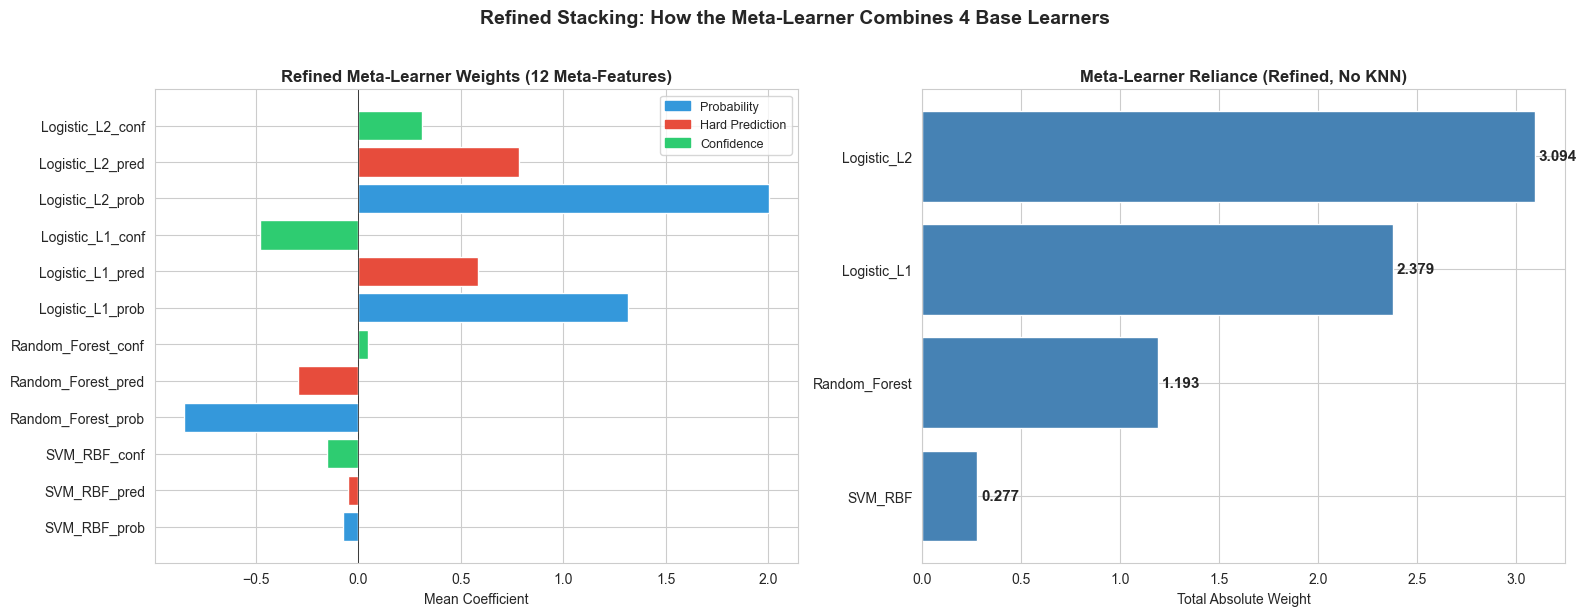

In [8]:
# Visualize refined meta-learner weights
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mean_w = weights_df_4.loc['Mean']
colors = []
for name in feat_names_4:
    if '_prob' in name:
        colors.append('#3498db')
    elif '_pred' in name:
        colors.append('#e74c3c')
    else:
        colors.append('#2ecc71')

axes[0].barh(feat_names_4, mean_w.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Mean Coefficient')
axes[0].set_title('Refined Meta-Learner Weights (12 Meta-Features)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#3498db', label='Probability'),
    Patch(color='#e74c3c', label='Hard Prediction'),
    Patch(color='#2ecc71', label='Confidence'),
], fontsize=9)

# Aggregate by base learner
model_total = {}
for name in REFINED_LEARNERS.keys():
    model_feats = [f for f in feat_names_4 if f.startswith(name)]
    model_total[name] = mean_w[model_feats].abs().sum()

model_series = pd.Series(model_total).sort_values(ascending=True)
axes[1].barh(model_series.index, model_series.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Total Absolute Weight')
axes[1].set_title('Meta-Learner Reliance (Refined, No KNN)', fontsize=12, fontweight='bold')
for i, (name, val) in enumerate(model_series.items()):
    axes[1].text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Refined Stacking: How the Meta-Learner Combines 4 Base Learners',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/refined_meta_learner_weights.png', bbox_inches='tight')
plt.show()

## 8. Full Comparison: All Approaches

In [9]:
# Build comprehensive comparison
all_comparison = {}

# Refined stacking (4 models)
all_comparison['Stacking (4-model refined)'] = results_4model['mean_metrics']

# 5-model stacking
all_comparison['Stacking (5-model)'] = results_5model['mean_metrics']

# NB04 tuned individual models
nb04_results = pd.read_csv('../results/tuned_results.csv', index_col=0)
for model_name in nb04_results.index:
    all_comparison[f'{model_name} (NB04)'] = nb04_results.loc[model_name].to_dict()

all_comp_df = results_to_dataframe(all_comparison)
print('--- FULL COMPARISON: All Approaches ---\n')
print(all_comp_df.to_string())

--- FULL COMPARISON: All Approaches ---

                            accuracy  balanced_accuracy  sensitivity  specificity  precision      f1     mcc  auc_roc
Model                                                                                                                
Stacking (4-model refined)    0.7811             0.7491       0.7982       0.7000     0.8980  0.8400  0.4530   0.8661
Stacking (5-model)            0.7614             0.7008       0.8184       0.5833     0.8635  0.8354  0.3734   0.8175
SVM_RBF (NB04)                0.7112             0.6706       0.7579       0.5833     0.8447  0.7925  0.3118   0.8123
SVM_Linear (NB04)             0.7512             0.7193       0.7719       0.6667     0.8824  0.8197  0.3920   0.8403
KNN (NB04)                    0.8211             0.7175       0.9184       0.5167     0.8595  0.8850  0.4267   0.9127
Random_Forest (NB04)          0.7789             0.6776       0.8720       0.4833     0.8440  0.8546  0.3311   0.8862
Logistic_L1 (NB

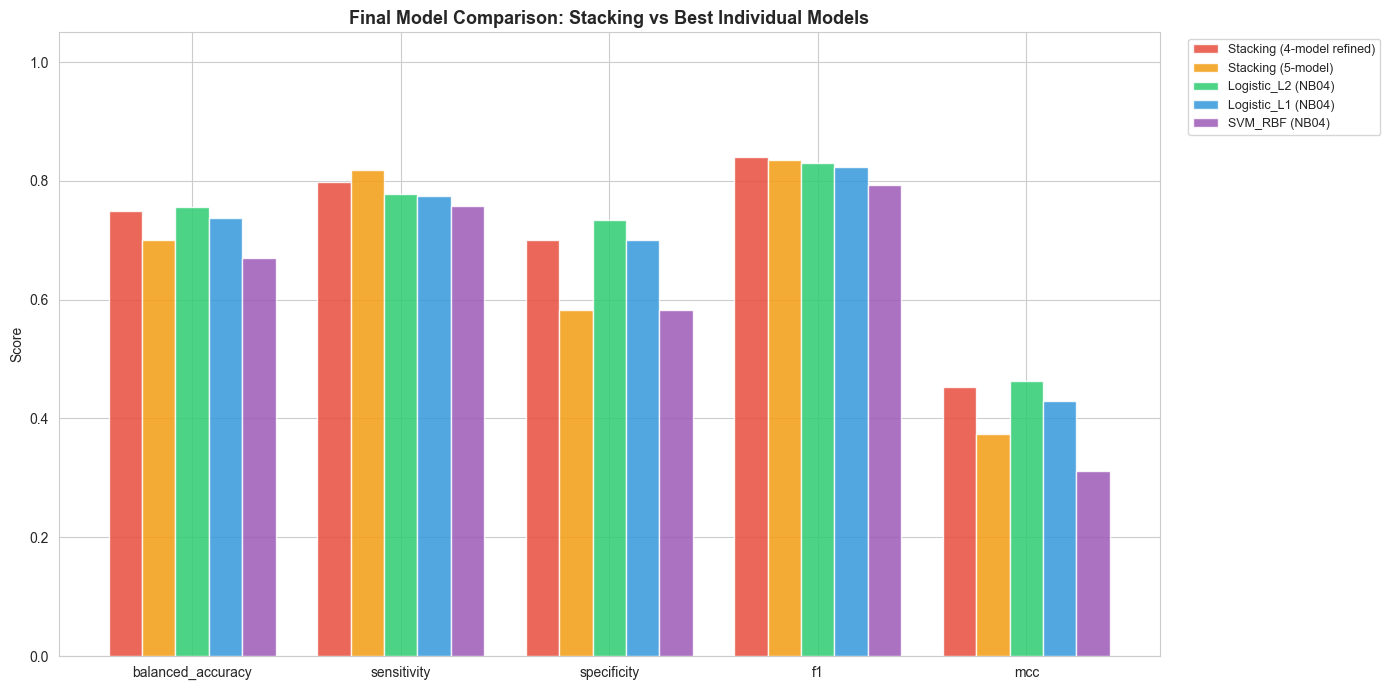

In [10]:
# Visualize the key contenders
key_models = ['Stacking (4-model refined)', 'Stacking (5-model)',
              'Logistic_L2 (NB04)', 'Logistic_L1 (NB04)', 'SVM_RBF (NB04)']
key_models = [m for m in key_models if m in all_comp_df.index]

metrics_to_plot = ['balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'mcc']

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(metrics_to_plot))
n = len(key_models)
width = 0.8 / n

colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

for i, model in enumerate(key_models):
    vals = [all_comp_df.loc[model, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=model, color=colors[i], alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Final Model Comparison: Stacking vs Best Individual Models',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * (n - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../figures/final_model_comparison.png', bbox_inches='tight')
plt.show()

## 9. Confusion Matrices — Key Models

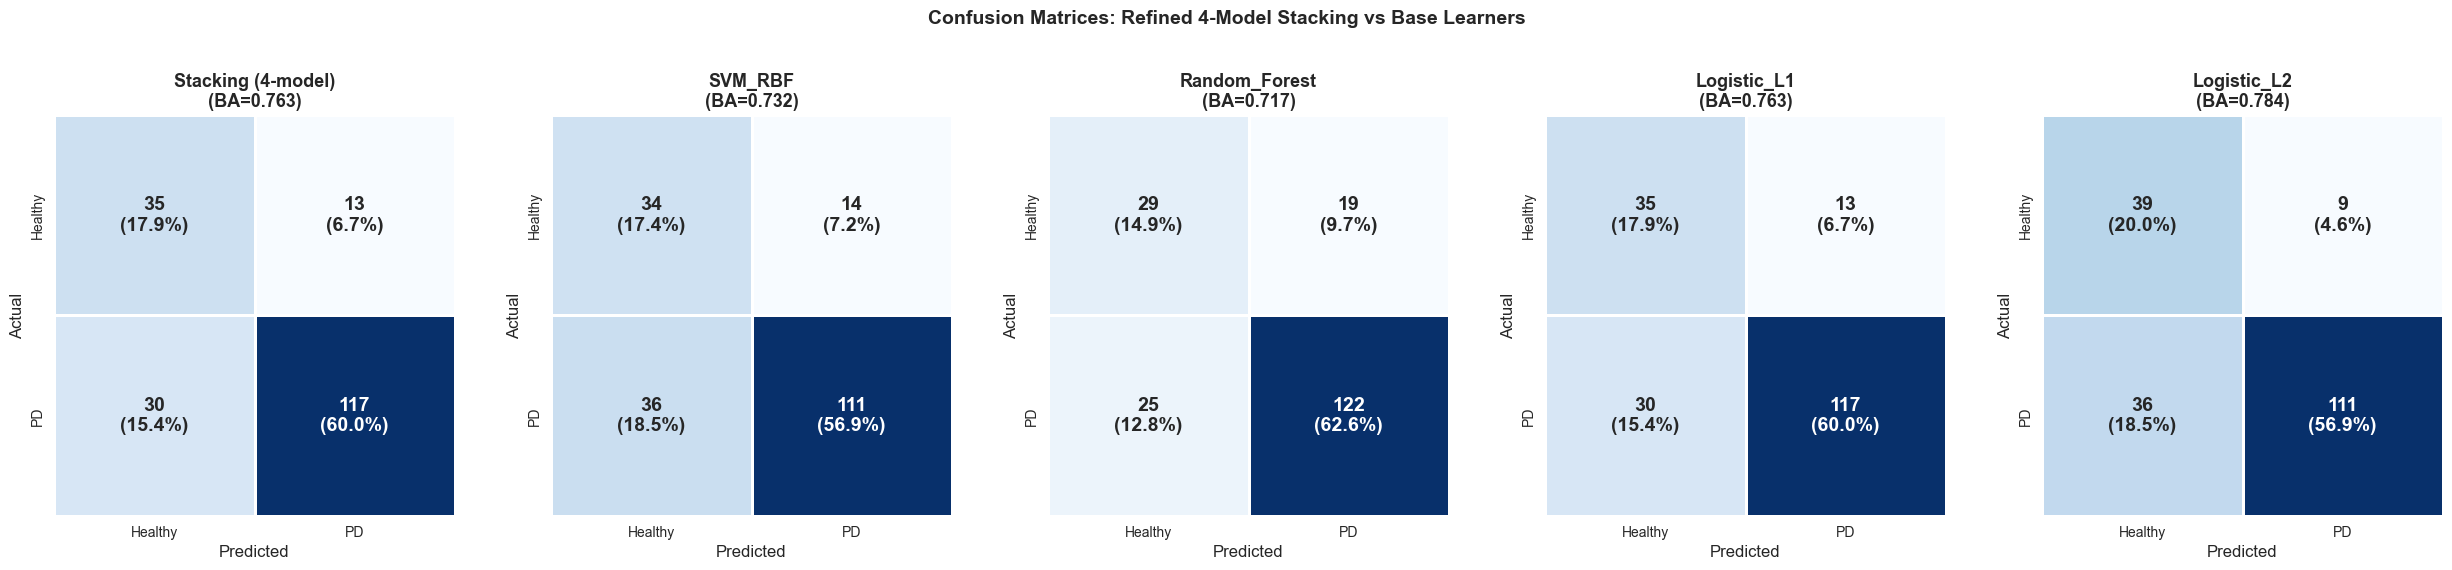

In [11]:
# Confusion matrices for refined stacking + base learners from the same CV
all_yt_4 = np.concatenate(results_4model['y_trues'])
all_yp_4 = np.concatenate(results_4model['y_preds'])

# Build CM dict for refined stacking base learners
cm_models = {'Stacking (4-model)': (all_yt_4, all_yp_4)}
for name in REFINED_LEARNERS:
    yt = np.concatenate(results_4model['base_y_trues'][name])
    yp = np.concatenate(results_4model['base_y_preds'][name])
    cm_models[name] = (yt, yp)

n_plots = len(cm_models)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for ax, (name, (yt, yp)) in zip(axes, cm_models.items()):
    ba = compute_metrics(yt, yp)['balanced_accuracy']
    plot_confusion_matrix(yt, yp, title=f'{name}\n(BA={ba:.3f})', ax=ax)

plt.suptitle('Confusion Matrices: Refined 4-Model Stacking vs Base Learners',
             fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig('../figures/refined_stacking_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10. Save Results

In [12]:
# Save all stacking results
def save_stacking_results(results, prefix):
    res_dict = {
        'metric': list(results['mean_metrics'].keys()),
        'mean': list(results['mean_metrics'].values()),
        'std': list(results['std_metrics'].values()),
    }
    pd.DataFrame(res_dict).to_csv(f'../results/{prefix}_results.csv', index=False)

save_stacking_results(results_5model, 'stacking_5model')
save_stacking_results(results_4model, 'stacking_4model_refined')

ablation_df.to_csv('../results/stacking_ablation.csv')
all_comp_df.to_csv('../results/final_model_comparison.csv')
weights_df_4.to_csv('../results/refined_meta_learner_weights.csv')

print('Saved to results/:')
print('  stacking_5model_results.csv')
print('  stacking_4model_refined_results.csv')
print('  stacking_ablation.csv')
print('  final_model_comparison.csv')
print('  refined_meta_learner_weights.csv')

Saved to results/:
  stacking_5model_results.csv
  stacking_4model_refined_results.csv
  stacking_ablation.csv
  final_model_comparison.csv
  refined_meta_learner_weights.csv


## 11. Key Takeaways

Fill in after running:

### 5-Model Stacking
1. **Balanced accuracy**: ___ ± ___ (improved from original 0.658 ± 0.213 via enriched meta-features)
2. **Ablation identified KNN as harmful** — removing it improved BA from ___ to ___

### Refined 4-Model Stacking (No KNN)
3. **Balanced accuracy**: ___ ± ___
4. **Sensitivity / Specificity**: ___ / ___
5. **Per-fold variance**: Has it decreased compared to 5-model stacking?

### Final Comparison
6. **Does refined stacking beat Logistic_L2 (NB04: 0.7558)?**
7. **Best overall model and configuration**: ___
8. **Meta-learner weights**: Which base learner does the refined meta-learner rely on most?

### Report Narrative
9. The stacking investigation demonstrates that ensemble methods do not automatically improve over well-tuned individual models on small datasets. The systematic ablation-driven refinement (removing KNN) illustrates principled model selection.

**Next step**: Notebook 06 — Final Results Compilation